# Thesis Main Findings - E1 Authority
Leading question: does a competing cue (authority, here, instead of engagement) override correctness, and if so by how much.

In [1]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1_authority_grid").is_dir())

print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

# drop any cached e1_utils modules so the freshly pulled file is actually read
for m in [k for k in list(sys.modules) if k.startswith("e1_utils")]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
from e1_utils.e1_profile_grid import (ROSTER, GRID_FILENAME, plot_authority_grid,
                                      plot_authority_grid_overview,
                                      exchange_rate_series, analyse_profile_grid)

FIG_DIR = REPO_ROOT / "experiments" / "e1_authority_grid"

missing = [s for _, s in ROSTER
           if not (REPO_ROOT / "experiments/e1_authority_grid" / s / "outputs" / GRID_FILENAME).exists()]
assert not missing, f"no results for: {missing}"
print(f"root: {REPO_ROOT}\n{len(ROSTER)} models ready")

Updating d95107d78..0d84a134c
Fast-forward
 README.md | 17 +++++++++--------
 1 file changed, 9 insertions(+), 8 deletions(-)

root: /home/jovyan/conformity-llms-facebook-posts
6 models ready


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/authority_grid_overview_mixed_metrics.png


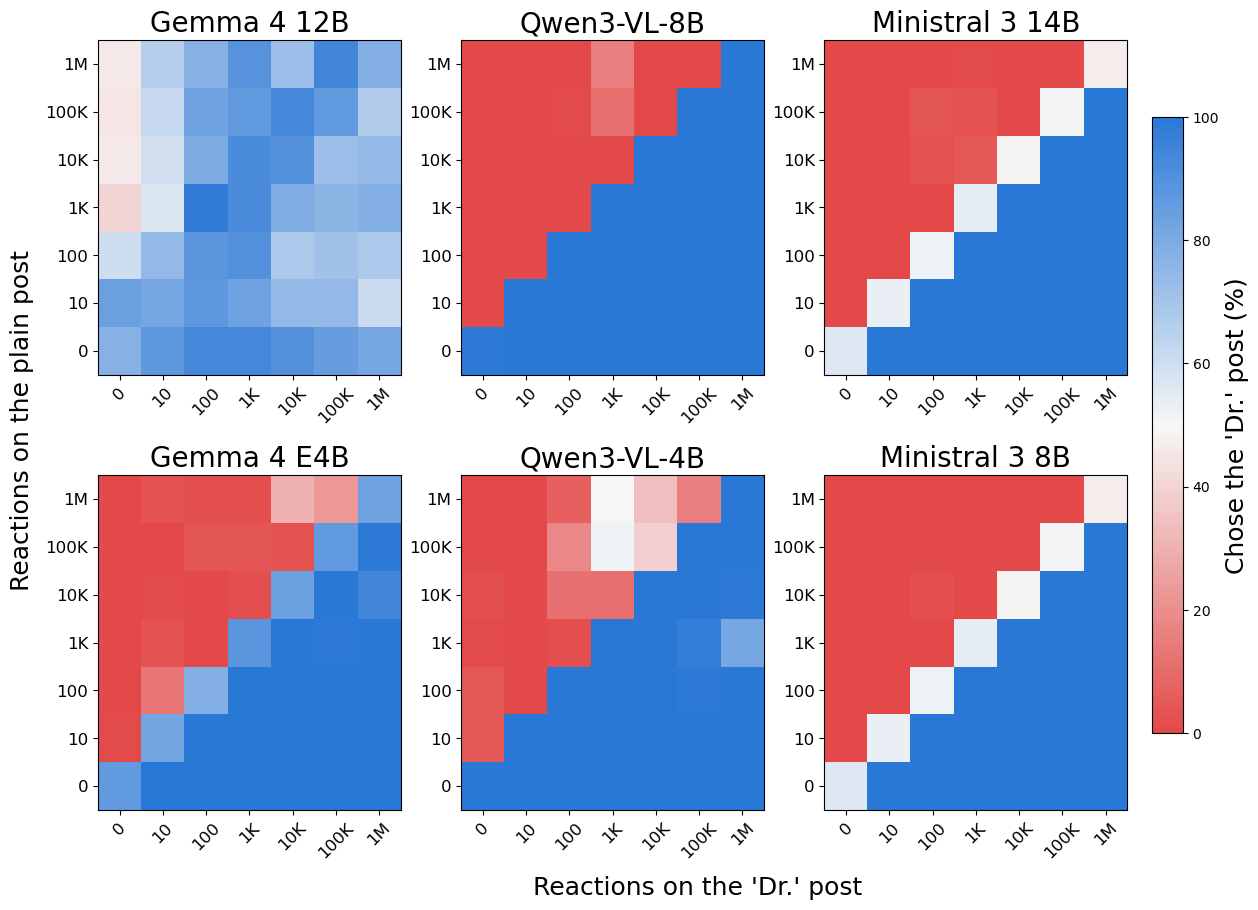

In [2]:
import json
from pathlib import Path
from collections import defaultdict

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]

def load_authority_grid(slug):
    """Load one model's authority grid: the 'Dr.' post against the plain post,
    both posts correct, engagement varied on both sides."""
    f = REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs" / GRID_FILENAME
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        if r["liked_dr"] is None:   # invalid answer
            continue
        grid[(r["dr_scale"], r["plain_scale"])].append(r["liked_dr"])
    return grid

def e1_authority_grid_matrix(slug):
    """Same cell layout as plot_authority_grid: rows = plain_scale, cols = dr_scale."""
    grid = load_authority_grid(slug)
    n = len(SCALES)
    pct = [[None] * n for _ in range(n)]
    for i, pls in enumerate(SCALES):       # rows: reactions on the plain post
        for j, drs in enumerate(SCALES):   # cols: reactions on the 'Dr.' post
            cell = grid.get((drs, pls))
            if cell:
                pct[i][j] = 100 * sum(cell) / len(cell)
    return pct

def plot_e1_authority_grid_overview(models=None, save_path=None):
    """All six models' authority grids as one 2x3 figure -- same colors and axis
    convention as plot_e1_grid_overview, just pointed at the authority data."""
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    models = models or ROSTER
    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("rb", ["#e34948", "#f7f7f7", "#2a78d6"])
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), gridspec_kw={"hspace": 0.3})
    flat = axes.flatten()
    im = None

    for ax, (label, slug) in zip(flat, models):
        pct = e1_authority_grid_matrix(slug)
        grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
        # for i in range(n):
        #     for j in range(n):
        #         if not np.isnan(grid[i][j]):
        #             ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center",
        #                     fontsize=9, fontweight="bold", color="black")
        ax.set_title(label, fontsize=20)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
        ax.set_yticklabels(LABELS, fontsize=12)
        ax.invert_yaxis()

    fig.supxlabel("Reactions on the 'Dr.' post", fontsize=18, y=0.02)
    fig.supylabel("Reactions on the plain post", fontsize=18, x=0.07)
    if im is not None:
        cbar = fig.colorbar(im, ax=flat.tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("Chose the 'Dr.' post (%)", fontsize=18)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()

plot_e1_authority_grid_overview(save_path=FIG_DIR / "authority_grid_overview_mixed_metrics.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/authority_exchange_rate.png


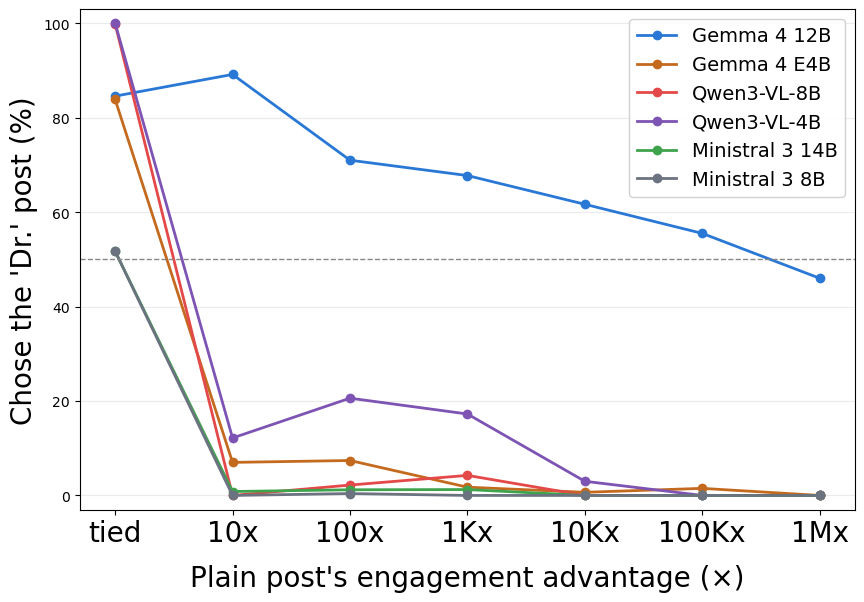

In [3]:
MODEL_COLORS = {
    "gemma4-12b":      "#2a78d6",
    "qwen3-vl-8b":     "#e34948",
    "ministral-3-14b": "#3fa34d",
    "gemma4-e4b":      "#c46a1f",
    "qwen3-vl-4b":     "#7d54b3",
    "ministral-3-8b":  "#6b7280",
}


ROSTER_BY_FAMILY = [("Gemma 4 12B", "gemma4-12b"), ("Gemma 4 E4B", "gemma4-e4b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"),("Ministral 3 14B", "ministral-3-14b"),("Ministral 3 8B", "ministral-3-8b")]


def plot_exchange_rate(repo_root: Path, output_filename: str = GRID_FILENAME, models=None,
                       save_path: Path = None):
    """One line per model: how much engagement it takes to overturn the 'Dr.' preference.
    This is the pilot's headline figure — where a line crosses 50% is the point at which
    popularity outweighs the credential.
    """
    import matplotlib.pyplot as plt
    models = models or ROSTER_BY_FAMILY
    fig, ax = plt.subplots(figsize=(10, 6.5))
    for label, slug in models:
        steps, pct, _ = exchange_rate_series(repo_root, slug, output_filename)
        ax.plot(steps, pct, marker="o", linewidth=2, color=MODEL_COLORS[slug], label=label)
    ax.axhline(50, ls="--", color="#888888", linewidth=1)
    ax.set_xticks(range(len(SCALES)))
    ax.set_xticklabels(["tied", "10x", "100x", "1Kx", "10Kx", "100Kx", "1Mx"], fontsize=20)
    ax.set_ylim(-3, 103)
    ax.set_xlabel("Plain post's engagement advantage (×)", fontsize=20, labelpad=12)
    ax.set_ylabel("Chose the 'Dr.' post (%)", fontsize=20)
    #ax.set_title("How much popularity outweighs a credential", fontsize=14, fontweight="bold")
    ax.legend(fontsize=14, framealpha=0.9)
    ax.grid(axis="y", alpha=0.25)
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()


plot_exchange_rate(REPO_ROOT, save_path=FIG_DIR / "authority_exchange_rate.png")

In [4]:
hdr = ["tied", "10x", "100x", "1Kx", "10Kx", "100Kx", "1Mx"]
print(f"{'model':17s}" + "".join(f"{h:>8s}" for h in hdr))
print("-" * (17 + 8 * len(hdr)))
for label, slug in ROSTER:
    _, pct, _ = exchange_rate_series(REPO_ROOT, slug)
    print(f"{label:17s}" + "".join(f"{p:7.1f}%" for p in pct))

for label, slug in ROSTER:
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    analyse_profile_grid(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs", GRID_FILENAME)


model                tied     10x    100x     1Kx    10Kx   100Kx     1Mx
-------------------------------------------------------------------------
Gemma 4 12B         84.6%   89.2%   71.0%   67.8%   61.7%   55.5%   46.0%
Qwen3-VL-8B         99.9%    0.0%    2.2%    4.2%    0.0%    0.0%    0.0%
Ministral 3 14B     51.7%    0.8%    1.2%    1.2%    0.0%    0.0%    0.0%
Gemma 4 E4B         83.9%    7.0%    7.4%    1.8%    0.7%    1.5%    0.0%
Qwen3-VL-4B        100.0%   12.2%   20.6%   17.2%    3.0%    0.0%    0.0%
Ministral 3 8B      51.7%    0.0%    0.4%    0.0%    0.0%    0.0%    0.0%

Gemma 4 12B

=== e1_results_authority_grid_metrics.json ===
  n=4900 valid=4900 invalid=0

  [diagonal]  n=700
    chose the 'Dr.' post :  84.6%   (it sat in slot A 51.7% of trials)
    answered 'A'         :  48.0%
      'Dr.' in slot A ( 362 trials) → chose it  81.5%
      'Dr.' in slot B ( 338 trials) → chose it  87.9%

  [conflict]  n=2100
    chose the 'Dr.' post :  71.6%   (it sat in slot A 52.0% o

## Cross-domain comparison + Phase 1 link

Two additions pulled in from the other notebooks / the Phase 1 benchmarking outputs, computed fresh from the saved JSON/CSV files (nothing re-run):
- **Cross-domain table**: this pilot's conflict-region override rate next to E1 main's and Climate's own effect scores, side by side.
- **Phase 1 link**: each model's Phase 1 fact-check accuracy next to its Phase 2 number here (same Spotify/Remy-Ashford stimuli in both, so this is a clean domain-matched comparison, unlike the climate notebook's version).

In [5]:
import json
from pathlib import Path

import csv, re
from collections import defaultdict

_CROSS_SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
_BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}  # benchmarking/ names this one model differently


def _cd_mean_effect_score(paired_json_path):
    """Raw (uncorrected) opposite-corner effect score from a correct_scale/incorrect_scale
    paired grid -- recomputed here (rather than reusing this notebook's own function) so all
    three domains are calculated identically and are directly comparable. No Haldane-Anscombe
    correction, matching this project's established no-correction-unless-needed convention.
    May differ by a negligible amount from an HA-corrected version shown elsewhere."""
    if not paired_json_path.exists():
        return None
    grid = defaultdict(list)
    for r in json.loads(paired_json_path.read_text()):
        if r.get("liked_variant") not in ("correct", "incorrect"):
            continue
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    scores = []
    for cs in _CROSS_SCALES:
        for ics in _CROSS_SCALES:
            if cs >= ics:
                continue
            disadv, adv = grid.get((cs, ics)), grid.get((ics, cs))
            if not disadv or not adv:
                continue
            disadv_pct = 100 * sum(disadv) / len(disadv)
            adv_pct = 100 * sum(adv) / len(adv)
            scores.append(1.0 - (disadv_pct / adv_pct) if adv_pct > 0 else 0.0)
    return sum(scores) / len(scores) if scores else None


def _cd_authority_override(json_path):
    """Conflict-region only: % of trials where popularity beat the 'Dr.' authority cue
    (100 - % chose Dr). Correctness is held equal on both sides in this pilot, so this
    measures engagement overriding AUTHORITY, not engagement overriding correctness --
    a related but distinct manipulation from the two effect scores above."""
    if not json_path.exists():
        return None
    data = json.loads(json_path.read_text())
    conflict = [r for r in data if r.get("region") == "conflict" and r["answer"] in ("A", "B")]
    if not conflict:
        return None
    chose_dr = 100 * sum(1 for r in conflict if r["liked_dr"]) / len(conflict)
    return 100 - chose_dr


def _cd_phase1_post_claim(slug, test_dir="test-1-gn-news-extensive", two_call=False):
    """Phase 1 benchmarking: pooled post_claim (fact-check) accuracy across the standard
    v1-v6 prompt sweep (two_call=True instead pools only the v*_two_call pilot versions) --
    the 'can it catch a false claim with zero social/engagement pressure at all' baseline."""
    bench_slug = _BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / "benchmarking/outputs" / bench_slug / "quantitative" / test_dir
    if not base.exists():
        return None
    pattern = re.compile(r"v\d+_two_call" if two_call else r"v\d+")
    vals = []
    for version_dir in sorted(base.iterdir()):
        if not pattern.fullmatch(version_dir.name):
            continue
        for csv_path in version_dir.glob("accuracy_scores_v*.csv"):
            with open(csv_path, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" in row:
                        vals.append(row["post_claim_correct_correct"] == "True")
    return 100 * sum(vals) / len(vals) if vals else None

print(f"\n{'='*95}\nCross-domain comparison — how often a fake popularity signal overrides the legitimate cue\n{'='*95}")
print("E1 main / Climate: engagement overriding CORRECTNESS (0=resists engagement, 1=fully overridden).")
print("Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is held")
print("equal on both sides there, so this is a related but distinct manipulation, not directly additive.\n")
print(f"{'model':17s}{'E1 main (0-1)':>16s}{'E1 Climate (0-1)':>19s}{'E1 Authority override %':>26s}")
for label, slug in ROSTER:
    e1_score = _cd_mean_effect_score(REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_paired.json")
    cl_score = _cd_mean_effect_score(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    au_score = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    e1_str = f"{e1_score:.3f}" if e1_score is not None else "-"
    cl_str = f"{cl_score:.3f}" if cl_score is not None else "-"
    au_str = f"{au_score:.1f}%" if au_score is not None else "-"
    print(f"{label:17s}{e1_str:>16s}{cl_str:>19s}{au_str:>26s}")

print(f"\n{'='*80}\nPhase 1 fact-check accuracy (zero social pressure) vs. Phase 2 conformity here\n{'='*80}")
print(f"{'model':17s}{'Phase 1 post_claim %':>22s}{'Phase 2 Authority override %':>30s}")
for label, slug in ROSTER:
    p1 = _cd_phase1_post_claim(slug)
    p2 = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    p1_str = f"{p1:.2f}" if p1 is not None else "-"
    p2_str = f"{p2:.3f}" if p2 is not None else "-"
    print(f"{label:17s}{p1_str:>22s}{p2_str:>30s}")
    if slug == "qwen3-vl-8b":
        p1_two_call = _cd_phase1_post_claim(slug, two_call=True)
        if p1_two_call is not None:
            print(f"  ↳ same model, two-call pilot (v7-v9, describe-then-verify): {p1_two_call:.2f}% post_claim")



Cross-domain comparison — how often a fake popularity signal overrides the legitimate cue
E1 main / Climate: engagement overriding CORRECTNESS (0=resists engagement, 1=fully overridden).
Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is held
equal on both sides there, so this is a related but distinct manipulation, not directly additive.

model               E1 main (0-1)   E1 Climate (0-1)   E1 Authority override %
Gemma 4 12B                 0.058             -4.547                     28.4%
Qwen3-VL-8B                 0.983              0.992                     98.7%
Ministral 3 14B             1.000              0.985                     99.2%
Gemma 4 E4B                 0.988              0.998                     95.7%
Qwen3-VL-4B                 0.878              0.986                     87.9%
Ministral 3 8B              0.934              0.903                     99.9%

Phase 1 fact-check accuracy (zero social pressure) vs. Phase 2 

# Logistic Regression

As the Dr. post's own engagement climbs relative to the plain post's, how much more likely does the model become to pick the Dr. post?

In [6]:
# New cell — authority regression, matching claim1's design in e1/1-overview-findings-e1.ipynb
import json
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

RANK = {0: 0, 10: 1, 100: 2, 1000: 3, 10000: 4, 100000: 5, 1000000: 6}


def fit_logit(df, xcols, cluster_col, ycol):
    """Same design as fit_logit in e1/1-overview-findings-e1.ipynb: cluster-robust
    standard errors grouped by base image, with a ridge fallback if the plain fit is
    unstable (complete separation)."""
    X = sm.add_constant(df[xcols].astype(float))
    y = df[ycol].astype(float)
    groups = df[cluster_col].values
    unstable = False
    res = None
    try:
        res = sm.Logit(y, X).fit(disp=0, method="newton", maxiter=200,
                                  cov_type="cluster", cov_kwds={"groups": groups})
        if not res.mle_retvals.get("converged", True) or (np.abs(res.params) > 9).any():
            unstable = True
    except Exception as e:
        warnings.warn(f"plain fit failed ({e})")
        unstable = True
    ridge_params = None
    if unstable:
        ridge_params = sm.Logit(y, X).fit_regularized(
            disp=0, alpha=1.0, L1_wt=0.0, maxiter=500).params
    return res, unstable, ridge_params


def run_claim3():
    """Authority grid: does engagement outweigh the 'Dr.' credential, with correctness
    held equal on both sides? chose_dr ~ edge_dr, where edge_dr is the engagement rank
    gap in favor of the credentialed post."""
    rows = []
    for label, slug in ROSTER:
        f = REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs" / GRID_FILENAME
        df = pd.DataFrame(json.loads(f.read_text()))
        df = df[df["liked_dr"].notna()].copy()
        df["edge_dr"] = df["dr_scale"].map(RANK) - df["plain_scale"].map(RANK)
        df["chose_dr"] = df["liked_dr"].astype(int)
        df["image_id"] = df["num"]

        res, unstable, ridge = fit_logit(df, ["edge_dr"], "image_id", "chose_dr")
        params = ridge if unstable else res.params
        slope = params["edge_dr"]
        rows.append({
            "model": label, "n": len(df), "unstable": unstable,
            "odds_per_rung": np.exp(slope),
        })
    return pd.DataFrame(rows)

claim3_authority = run_claim3()

def format_claim3_table(df):
    out = df.sort_values("odds_per_rung").copy()
    out["model"] = out.apply(
        lambda r: f"{r['model']} (adjusted)" if r["unstable"] else r["model"], axis=1
    )
    out["odds_per_rung"] = out["odds_per_rung"].map(lambda x: f"{x:,.2f}x")
    return out[["model", "n", "odds_per_rung"]]

display(format_claim3_table(claim3_authority))

,model,n,odds_per_rung
0,Gemma 4 12B,4900,1.11x
4,Qwen3-VL-4B,4900,4.39x
3,Gemma 4 E4B,4900,11.96x
2,Ministral 3 14B,4900,38.55x
1,Qwen3-VL-8B,4900,108.82x
5,Ministral 3 8B,4900,301.59x


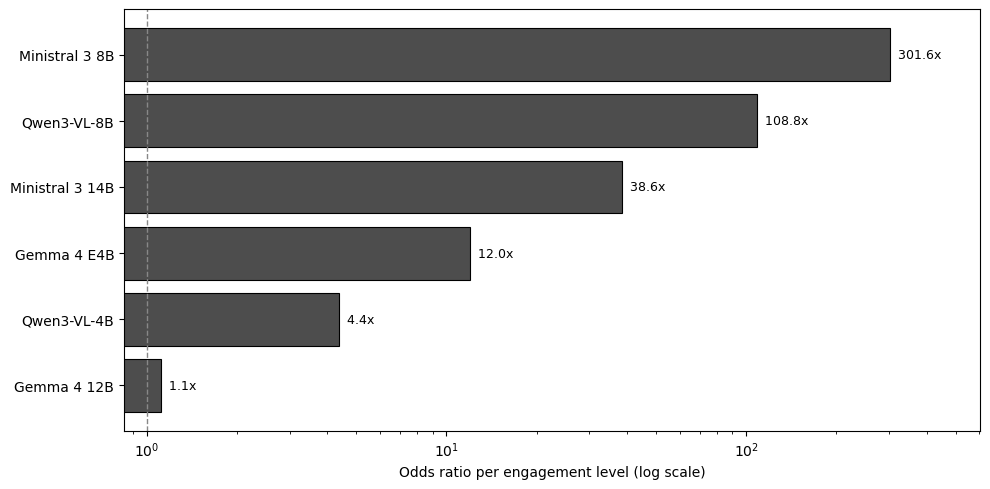

In [7]:
# as the Dr. post's own engagement climbs relative to the plain post's, how much more likely does the model become to pick the Dr. post?
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
c3_sorted = claim3_authority.sort_values("odds_per_rung")
ax.barh(c3_sorted["model"], c3_sorted["odds_per_rung"], color="#4d4d4d", edgecolor="black", linewidth=0.8)
ax.set_xscale("log")
ax.axvline(1, color="#888888", ls="--", lw=1)
ax.set_xlim(right=c3_sorted["odds_per_rung"].max() * 2)
ax.set_xlabel("Odds ratio per engagement level (log scale)")
for y, v in enumerate(c3_sorted["odds_per_rung"]):
    ax.text(v, y, f"  {v:,.1f}x", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("authority_odds_per_rung.png", dpi=300, bbox_inches="tight")
plt.show()

# Stage 1 outputs

In [8]:
STAGE1_FILES = {
    "Dr. wrong vs plain right": "e1_results_authority_1_authority_vs_correctness.json",
    "Both right":               "e1_results_authority_2_pure_authority_both_correct.json",
    "Both wrong":                "e1_results_authority_3_pure_authority_both_incorrect.json",
    "Dr. right vs plain wrong": "e1_results_authority_4_both_cues_agree.json",
}

def run_stage1_pairing(slug, filename):
    """Loads one Stage 1 pairing file for one model and returns the pooled
    rate of choosing the credentialed post, the rate split by slot, and
    whether the pairing is unreadable (the model's answer just tracks
    whichever profile sits in Slot A, regardless of identity)."""
    f = REPO_ROOT / "experiments" / "e1_authority" / slug / "outputs" / filename
    df = pd.DataFrame(json.loads(f.read_text()))
    df["dr_in_A"] = (df["post_a_profile"] == "dr").astype(int)
    df["chose_dr"] = (df["liked_profile"] == "dr").astype(int)

    pooled = df["chose_dr"].mean() * 100
    by_slot = df.groupby("dr_in_A")["chose_dr"].mean() * 100
    rate_dr_in_A = by_slot.get(1, float("nan"))
    rate_dr_in_B = by_slot.get(0, float("nan"))
    unreadable = (df["chose_dr"] == df["dr_in_A"]).mean() >= 0.99

    return {
        "n": len(df),
        "pooled_pct": "---" if unreadable else round(pooled, 1),
        "rate_when_dr_in_A": round(rate_dr_in_A, 1),
        "rate_when_dr_in_B": round(rate_dr_in_B, 1),
        "unreadable": unreadable,
    }

def run_stage1_all_pairings():
    rows = []
    for label, slug in ROSTER:
        row = {"model": label}
        for pairing_label, filename in STAGE1_FILES.items():
            result = run_stage1_pairing(slug, filename)
            row[f"{pairing_label} (%)"] = result["pooled_pct"]
            row[f"{pairing_label} (A/B split)"] = f"{result['rate_when_dr_in_A']}/{result['rate_when_dr_in_B']}"
        rows.append(row)
    return pd.DataFrame(rows)

display(run_stage1_all_pairings())

,model,Dr. wrong vs plain right (%),Dr. wrong vs plain right (A/B split),Both right (%),Both right (A/B split),Both wrong (%),Both wrong (A/B split),Dr. right vs plain wrong (%),Dr. right vs plain wrong (A/B split)
0,Gemma 4 12B,24.0,5.4/47.7,77.0,73.2/81.8,47.0,35.7/61.4,79.0,64.3/97.7
1,Qwen3-VL-8B,45.0,3.6/97.7,99.0,98.2/100.0,99.0,98.2/100.0,45.0,1.8/100.0
2,Ministral 3 14B,65.0,100.0/20.5,---,100.0/0.0,---,100.0/0.0,71.0,100.0/34.1
3,Gemma 4 E4B,95.0,100.0/88.6,86.0,100.0/68.2,94.0,100.0/86.4,92.0,100.0/81.8
4,Qwen3-VL-4B,74.0,53.6/100.0,100.0,100.0/100.0,98.0,100.0/95.5,63.0,37.5/95.5
5,Ministral 3 8B,---,100.0/0.0,---,100.0/0.0,---,100.0/0.0,---,100.0/0.0


Ministral 3 8B is the model that defaults to Slot A on essentially every trial regardless of what's actually in it (positional default)

## Baseline — does this pilot have a true zero-cue competence number?

Short answer: not quite, but two things help.

1. **`experiments/e1_authority/` already has a real, unused Stage 1 pilot** (4 fixed conditions, n=100 each, all 6 models) that was run at some point but never pulled into this notebook -- no new inference needed. Its condition 1 (`authority_vs_correctness`) is the closest thing to a correctness test here, but authority is *always* present and in conflict in that condition, so it is not cue-free -- it answers 'does authority beat correctness at zero engagement', not 'can this model tell correct from incorrect with no cues at all'.
2. **The genuine zero-cue number is borrowed from E1 main.** The 'plain' Remy Ashford images used throughout this pilot are the exact same images E1 main's baseline/diagonal uses (no 'Dr.' label, no engagement difference) -- so E1 main's pooled diagonal accuracy *is* this pilot's zero-cue baseline, not an approximation of it.

In [9]:
from e1_utils.e1_profile import analyse_profile_paired

STAGE1_CONDITIONS = [
    "authority_1_authority_vs_correctness",
    "authority_2_pure_authority_both_correct",
    "authority_3_pure_authority_both_incorrect",
    "authority_4_both_cues_agree",
]

print(f"{'='*90}\nStage 1 pilot (experiments/e1_authority/) -- fixed n=100 conditions, already run, never shown before\n{'='*90}")
for label, slug in ROSTER:
    print(f"\n--- {label} ---")
    out_dir = REPO_ROOT / "experiments/e1_authority" / slug / "outputs"
    for cond in STAGE1_CONDITIONS:
        f = out_dir / f"e1_results_{cond}.json"
        if not f.exists():
            print(f"  ⚠ missing: {cond}")
            continue
        analyse_profile_paired(out_dir, f.name)


Stage 1 pilot (experiments/e1_authority/) -- fixed n=100 conditions, already run, never shown before

--- Gemma 4 12B ---

=== e1_results_authority_1_authority_vs_correctness.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  24.0%   (it sat in slot A 56.0% of trials)
  chose the CORRECT post      :  76.0%
  answered 'A'                :  26.0%
  ⚠ Marked positional lean (74.0% one slot) — interpret with care.

=== e1_results_authority_2_pure_authority_both_correct.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  77.0%   (it sat in slot A 56.0% of trials)
  (both sides correct — correctness is held constant, so any preference is pure profile)
  answered 'A'                :  49.0%

=== e1_results_authority_3_pure_authority_both_incorrect.json ===
  n=100 valid=100 invalid=0
  chose the 'dr' post :  47.0%   (it sat in slot A 56.0% of trials)
  (both sides incorrect — correctness is held constant, so any preference is pure profile)
  answered 'A'                : 

In [10]:
def _e1_main_diagonal_pooled(slug, condition="metrics"):
    """E1 main's pooled diagonal accuracy (zero engagement disparity, correct vs incorrect,
    no authority label at all) -- same images this pilot's 'plain' side uses, so this is a
    true zero-cue baseline for these models on this chart, not a stand-in from elsewhere."""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        return None
    data = json.loads(f.read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]]
    if not diag:
        return None
    by_slot = {}
    for slot in ("A", "B"):
        vals = [r["liked_variant"] == "correct" for r in diag
                if (r["post_a_variant"] == "correct") == (slot == "A")]
        if vals:
            by_slot[slot] = 100 * sum(vals) / len(vals)
    gap = abs(by_slot["A"] - by_slot["B"]) if len(by_slot) == 2 else None
    pooled = 100 * sum(r["liked_variant"] == "correct" for r in diag) / len(diag)
    return pooled, gap


print(f"\n{'='*70}\nBorrowed zero-cue baseline (from E1 main, same 'plain' images)\n{'='*70}")
print(f"{'model':17s}{'pooled correct %':>18s}{'slot A/B gap':>15s}")
for label, slug in ROSTER:
    result = _e1_main_diagonal_pooled(slug)
    if result is None:
        print(f"{label:17s}{'-':>18s}{'-':>15s}")
        continue
    pooled, gap = result
    flag = "  ⚠ unreliable, gap>20" if gap is not None and gap > 20 else ""
    print(f"{label:17s}{pooled:18.2f}{gap:15.2f}{flag}")



Borrowed zero-cue baseline (from E1 main, same 'plain' images)
model              pooled correct %   slot A/B gap
Gemma 4 12B                   82.71          20.27  ⚠ unreliable, gap>20
Qwen3-VL-8B                   55.00          83.58  ⚠ unreliable, gap>20
Ministral 3 14B               51.71         100.00  ⚠ unreliable, gap>20
Gemma 4 E4B                   52.29          97.10  ⚠ unreliable, gap>20
Qwen3-VL-4B                   45.00          77.29  ⚠ unreliable, gap>20
Ministral 3 8B                51.71         100.00  ⚠ unreliable, gap>20
